In [1]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2025-11-21 12:27:41.393335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763728061.699068      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763728061.804225      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [3]:
train_path='/kaggle/input/brain-tumor-mri-dataset/Training'
test_path='/kaggle/input/brain-tumor-mri-dataset/Testing'

In [4]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 rotation_range=0.2,
                                 zoom_range=0.2,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 horizontal_flip=True)

In [5]:
train_data=train_datagen.flow_from_directory(
    shuffle=True,
    directory=train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical')

Found 5712 images belonging to 4 classes.


In [6]:
train_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [7]:
test_datagen=train_datagen=ImageDataGenerator(rescale=1./255)

In [8]:
test_data=train_datagen.flow_from_directory(shuffle=False,
    directory=test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical')

Found 1311 images belonging to 4 classes.


In [9]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img,ax in zip( images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

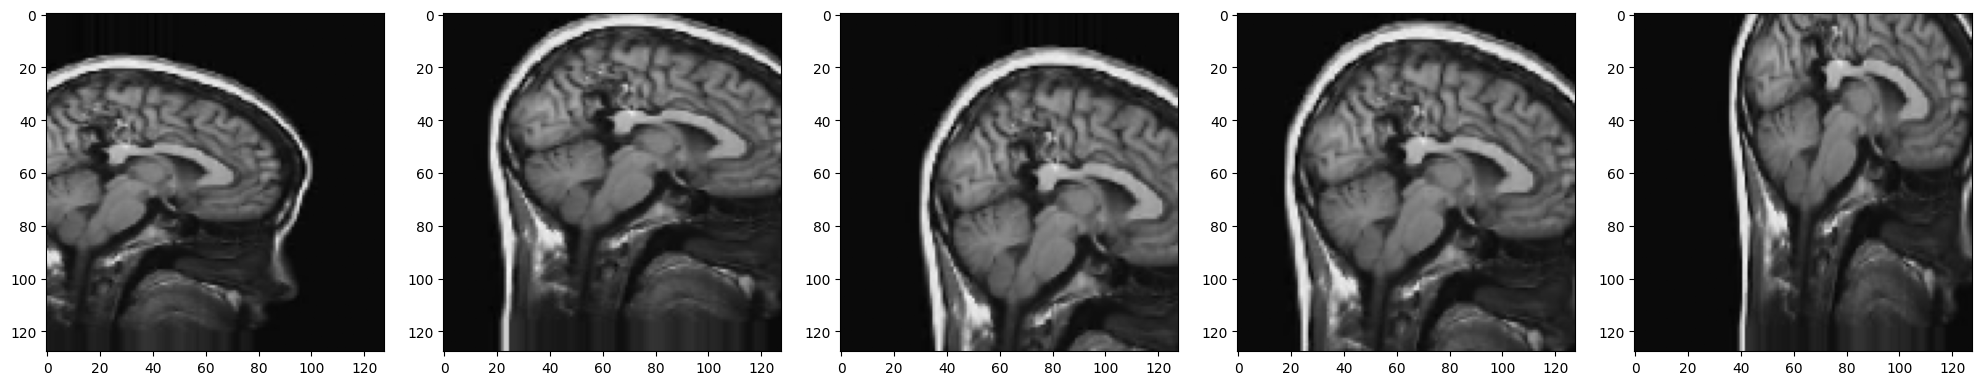

In [10]:
images=[train_data[0][0][0] for i in range(5)]
plotImages(images)

In [11]:
model=keras.models.Sequential()
model.add(keras.layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=256,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(units=128,activation='relu'))
model.add(keras.layers.Dropout(0.1))
model.add(keras.layers.Dense(units=256,activation='relu'))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(units=4,activation='softmax'))

2025-11-21 12:28:07.398290: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,860 (2.13 MB)

 Trainable params: 557,860 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [14]:
history=model.fit(train_data,epochs=40,validation_data=test_data)

Epoch 1/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 120s 642ms/step - accuracy: 0.3849 - loss: 1.2237 - val_accuracy: 0.5385 - val_loss: 1.0673
Epoch 2/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 399ms/step - accuracy: 0.5854 - loss: 0.9575 - val_accuracy: 0.4737 - val_loss: 1.1357
Epoch 3/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 71s 395ms/step - accuracy: 0.6760 - loss: 0.8103 - val_accuracy: 0.5408 - val_loss: 1.3831
Epoch 4/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 70s 392ms/step - accuracy: 0.7093 - loss: 0.7155 - val_accuracy: 0.6270 - val_loss: 0.9834
Epoch 5/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 70s 392ms/step - accuracy: 0.7603 - loss: 0.6338 - val_accuracy: 0.7818 - val_loss: 0.5513
Epoch 6/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 70s 392ms/step - accuracy: 0.7673 - loss: 0.5961 - val_accuracy: 0.7361 - val_loss: 0.7490
Epoch 7/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 71s 393ms/step - accuracy: 0.8058 - loss: 0.5133 - val_accuracy: 0.7307 - val_loss: 0.7586
Epoch 8/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 69s 385ms/step - accuracy: 0.8295 - loss: 

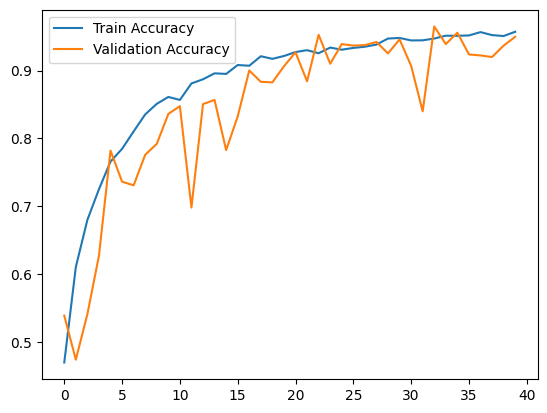

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

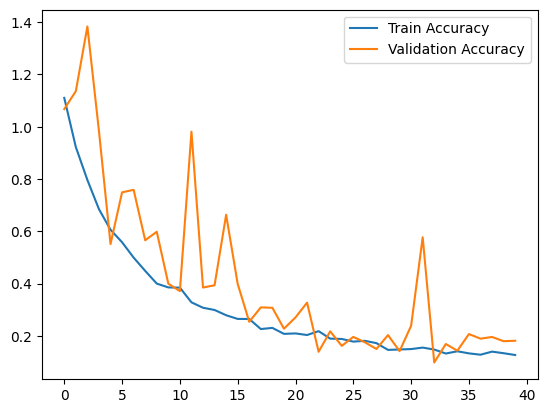

In [16]:
plt.plot(history.history['loss'], label='Train Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')
plt.legend()
plt.show()

In [17]:
y_prob=model.predict(test_data)

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step


In [18]:
y_true=test_data.classes

In [19]:
y_pred=np.argmax(y_prob,axis=1)

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
cm=confusion_matrix(y_true,y_pred)

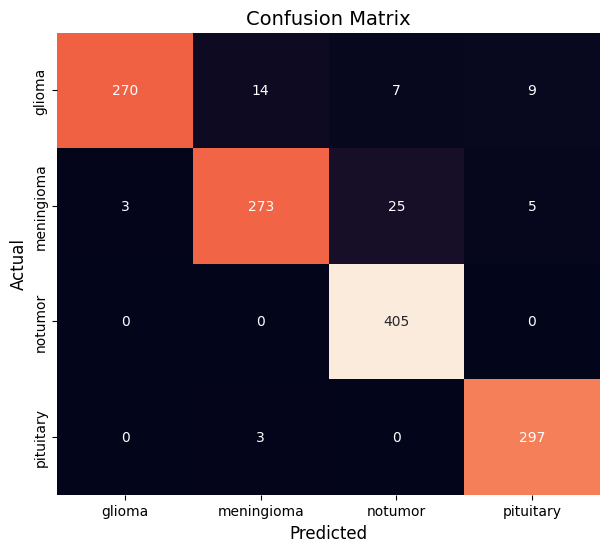

In [22]:
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [24]:
n_classes = 4
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

In [25]:
y_true = y_true
y_score = y_prob

In [26]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

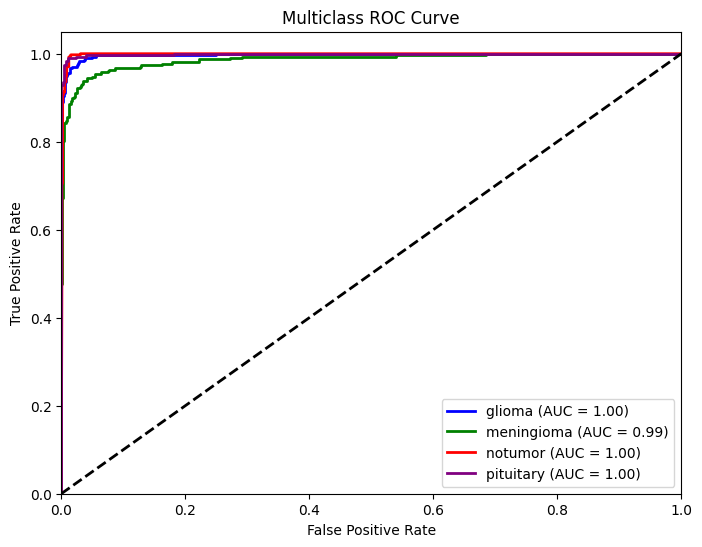

In [27]:
plt.figure(figsize=(8,6))

colors = ['blue', 'green', 'red', 'purple']
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [28]:
from sklearn.metrics import f1_score,precision_score,recall_score

In [29]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

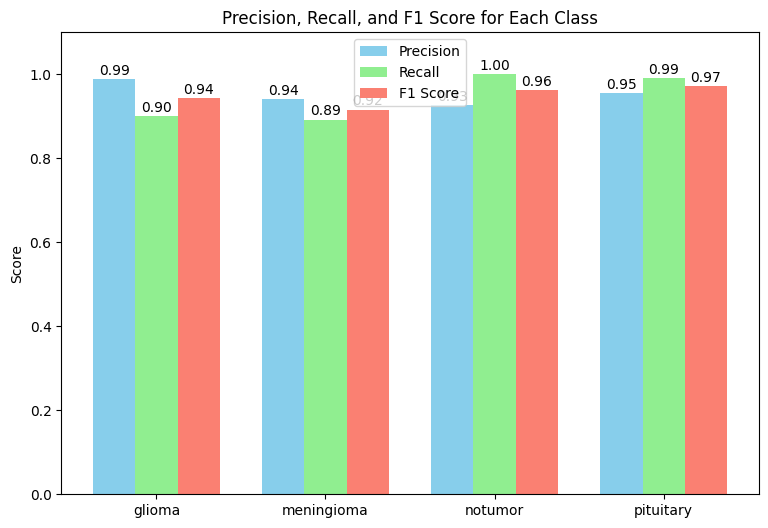

In [30]:
x = np.arange(len(class_names))  # label locations
width = 0.25  # width of each bar

plt.figure(figsize=(9,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1 Score', color='salmon')

# Add values on top of bars
for i in range(len(class_names)):
    plt.text(x[i] - width, precision[i]+0.01, f'{precision[i]:.2f}', ha='center', fontsize=10)
    plt.text(x[i], recall[i]+0.01, f'{recall[i]:.2f}', ha='center', fontsize=10)
    plt.text(x[i] + width, f1[i]+0.01, f'{f1[i]:.2f}', ha='center', fontsize=10)

plt.xticks(x, class_names)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score for Each Class')
plt.legend()
plt.show()


In [31]:
from sklearn.metrics import classification_report

In [32]:
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

              precision    recall  f1-score   support

      glioma       0.99      0.90      0.94       300
  meningioma       0.94      0.89      0.92       306
     notumor       0.93      1.00      0.96       405
   pituitary       0.95      0.99      0.97       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311

